# Start project for adding new sources

In [1]:
%reset -f
%run setup_notebook
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from utilities.ipynb_docgen import show, capture_hide

In [2]:
from like3.main import FermiFit
from like3.sourcelist import SourceModel
from like3.pixel_table import PixelTable
sm = SourceModel(sources=[])
pt = PixelTable('files/kerr/toby_v4.fits', source_model=sm)
ff = FermiFit(pt)

Loaded pixel table from "files/kerr/toby_v4.fits":
            42 bands Band(0, 4): PSF0@1.33 GeV nside 64 occ 1.001 ... Band(3, 11): PSF3@74.99 GeV nside 2048 occ 0.000
            193,317,496 photons
            8,240,918 pixels, order ring
            
Attached source model with 0 sources to pixel table
set_psf: 72 PSF entries (FRONT, BACK, PSF0, PSF1, PSF2, PSF3) from 'files/loc'


In [3]:
from utilities.catalogs import UWcat, Fermi4FGL
uw = UWcat('uw1617')
uw['glat'] = uw.skycoord.galactic.b.deg
fl16y = Fermi4FGL('uw1617')
uw_index = list(map(lambda s: s.replace('FL16', 'FL16Y'), uw.index)) 
uw.add_match(fl16y, 'FL16Y')
df = uw_not_in_fl16y = uw.query('FL16Y_delta>0.5')
show(f"""{len(uw_not_in_fl16y)}  UW sources sre 5 degrees away from any in FL16Y: """)

Loaded UW model uw1617: 12109 entries
Loaded Fermi 4FGL gll_pscP305uw1617_v8r4_assoc_v9r1p6_flags.fits: 7224 entries


4418  UW sources sre 5 degrees away from any in FL16Y: 

#### TS distribution of UW sources not in FL16Y

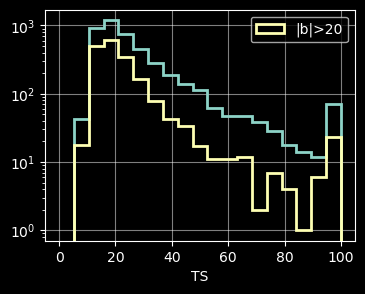

In [4]:
show(f"""#### TS distribution of UW sources not in FL16Y""")
fig, ax = plt.subplots(figsize=(4, 3))
ax.grid(True,alpha=0.5)
hkw = dict(histtype='step', lw=2, bins = np.linspace(0, 100, 20))
ax.set(xlabel='TS', yscale='log')
ax.hist(df.ts.clip(0,100), **hkw)
ax.hist(df[np.abs(df.glat)>20].ts.clip(0,100), label='|b|>20', **hkw);
ax.legend()
plt.show()

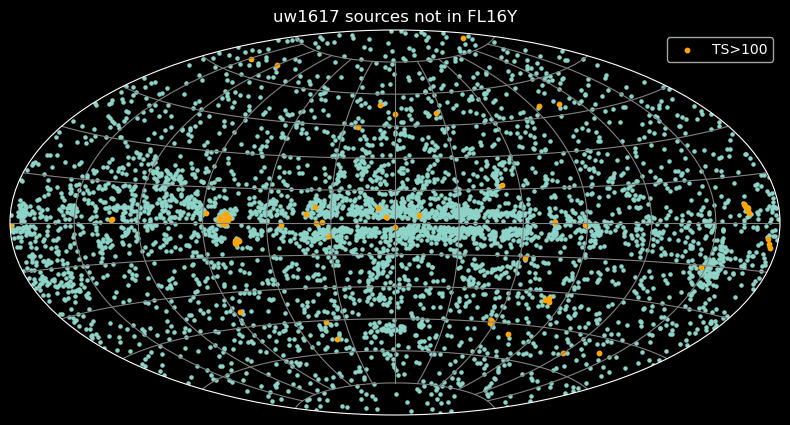

In [5]:
from utilities.skymaps import AITfigure
(AITfigure(figsize=(10, 5), title='uw1617 sources not in FL16Y')
 .scatter(df, s=5,).scatter(df.query('ts>100'), s=10, c='orange', label='TS>100')
 .legend().show()
)

In [6]:
show(f"""### Select the high-latitude sources with TS>100 as candidates for new sources to add to the model.""")
to_add = df.query('ts>100 and abs(glat)>20'); 
to_add['ts glat specfunc'.split()].sort_values(by='ts', ascending=False).round().head()
from like3.sources import LogParabola, PLSuperExpCutoff, PLSuperExpCutoff4
row  = to_add.iloc[1]
sm.add_source(name=row.name, skydir = (row['ra'], row['dec']), model=eval(str(row.specfunc)))

### Select the high-latitude sources with TS>100 as candidates for new sources to add to the model.

like3.sources.PointSource: 
	name  : 998S-0452
	icrs  : (013.512, -71.492)
	model : LogParabola
		Norm      : 4.39e-11 
		Index     : 3.5 
		beta      : 0.07 (FROZEN)
		E_break   : 200 (FROZEN)

In [7]:
src = sm.find_source(sm[0].name)
pt.build_coverage();
# 

In [8]:
kde_file = '/mnt/c/Users/thbur/OneDrive/fermi/skymodels/hptables_kde_512_16.fits'
from astropy.io import fits
with fits.open(kde_file) as hdul:
    kde = hdul['SKYMAP'].data['kde']

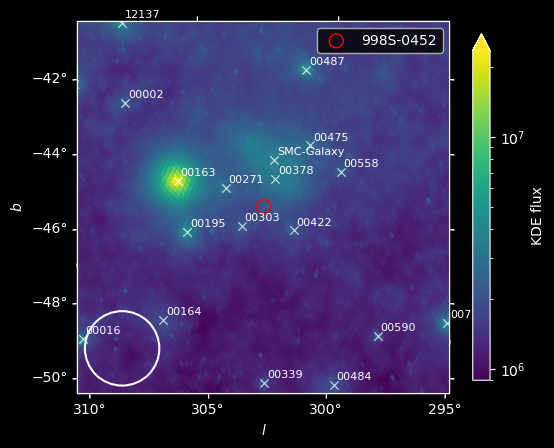

In [9]:
import like3.sky_display as _sky_display; reload(_sky_display)
zea_plot = _sky_display.zea_plot
sm.fermi_catalog = fl16y
(zea_plot(src.skydir, kde, size=10, r68=1,cmap='viridis',source_model=sm, label='KDE flux')
 .scatter(src.skydir, s=100, edgecolor='red', facecolor='none', label=src.name).legend().show()
)

<Axes: title={'center': '998S-0452'}, xlabel='Energy (MeV)', ylabel='$E^2\\,dN/dE\\ [\\mathrm{eV\\,cm^{-2}\\,s^{-1}}]$'>

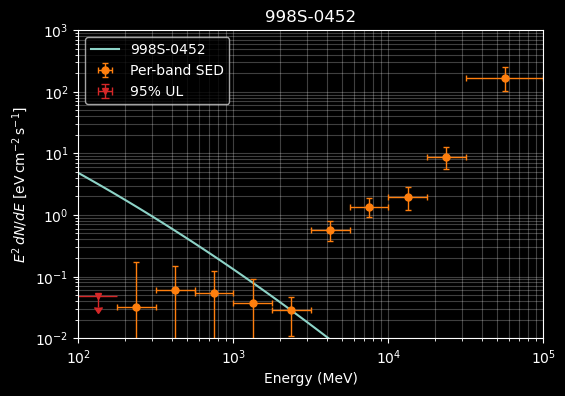

In [15]:
ff.plot_sed_with_band_points(ylim=(1e-2, 1e3))#, label='KDE flux');

In [11]:
sm[0].sedrec

,elow,ehigh,poiss,maxdev,wprime,flux,lflux,uflux,ts,fit_status,fail_reason
energy,,,,,,,,,,,
133,100.000000,177.827941,"Poisson: mu,beta= 513819.0, 514862.0",0.000400,-9.253253,0.000000,0.000000,0.048686,0.000000,ok,
237,177.827941,316.227766,"Poisson: mu,beta= 11959.7, 11933.9",0.027410,1.690633,0.032463,0.000000,0.170671,0.055586,ok,
421,316.227766,562.341325,"Poisson: mu,beta= 1236.4, 1211.9",0.034818,9.300448,0.060481,0.000000,0.147921,0.494111,ok,
749,562.341325,1000.000000,"Poisson: mu,beta= 284.5, 270.3",0.005570,13.712992,0.054693,0.000000,0.121268,0.726109,ok,
1333,1000.000000,1778.279410,"Poisson: mu,beta= 74.0, 67.9",0.033608,16.783014,0.037240,0.000000,0.091569,0.537187,ok,
2371,1778.279410,3162.277660,"Poisson: mu,beta= 69.1, 56.1",0.011334,105.774550,0.028362,0.010969,0.047207,2.811452,ok,
4216,3162.277660,5623.413252,"Poisson: mu,beta= 20.3, 8.1",0.014090,43.636151,0.578649,0.381114,0.807674,13.022075,ok,
7498,5623.413252,10000.000000,"Poisson: mu,beta= 17.5, 5.5",0.012411,31.936808,1.362065,0.924175,1.875492,16.477197,ok,
13335,10000.000000,17782.794100,"Poisson: mu,beta= 8.7, 1.7",0.015728,49.346732,1.935285,1.204921,2.851036,14.093520,ok,


<Axes: title={'center': 'FL1600327'}, xlabel='Energy (MeV)', ylabel='$E^2\\,dN/dE\\ [\\mathrm{eV\\,cm^{-2}\\,s^{-1}}]$'>

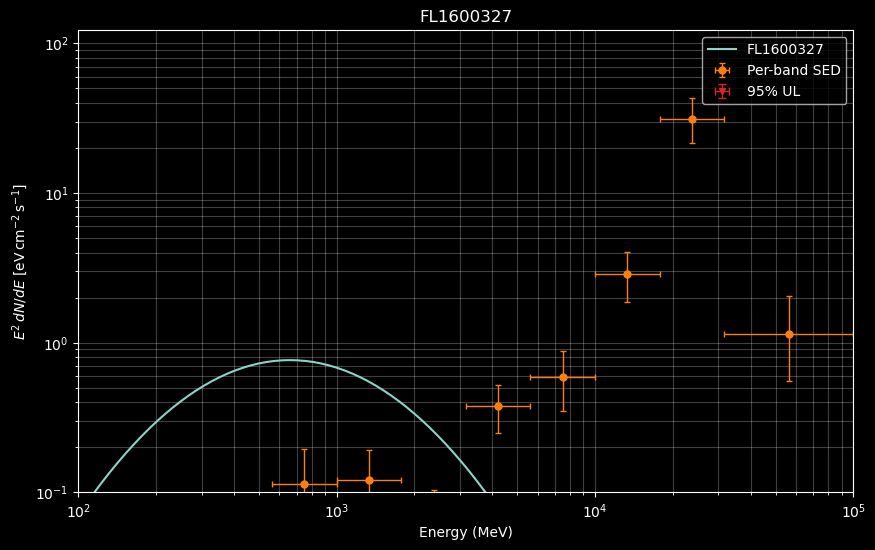

In [ ]:
ff.plot_sed_with_band_points();

<Axes: title={'center': 'FL1600327'}, xlabel='Energy (MeV)', ylabel='$E^2\\,dN/dE\\ [\\mathrm{eV\\,cm^{-2}\\,s^{-1}}]$'>

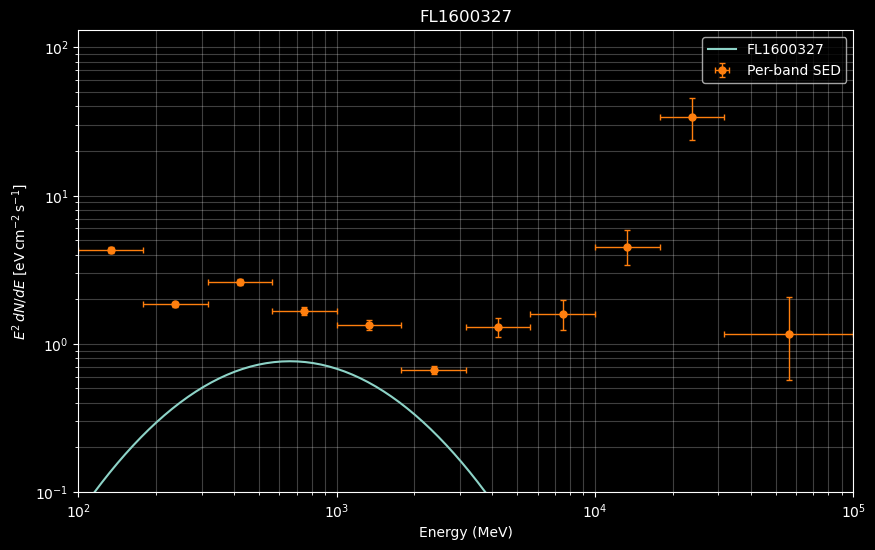

In [22]:
ff.plot_sed_with_band_points()